# Seismic events overlaid on a mine map

In [ ]:
!pip install geopandas matplotlib ezdxf ipyleaflet

In [ ]:
import math
import matplotlib.pyplot as plt

from branca.colormap import linear
from ipyleaflet import Map, GeoData, LayersControl, CircleMarker, LayerGroup, Popup
from ipywidgets import HTML
import ezdxf
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.affinity import translate, scale, rotate
from shapely.geometry import LineString, Point, Polygon

In [ ]:
thickness_between = gpd.read_file('mocnost mezilozi lines.shp')

# thickness_between.plot()
# plt.title('Mocnost meziloží')
# plt.show()

In [4]:
def arc_to_linestring(e, resolution=30):
    center = e.dxf.center
    radius = e.dxf.radius
    start_angle = math.radians(e.dxf.start_angle)
    end_angle = math.radians(e.dxf.end_angle)
    if end_angle < start_angle:
        end_angle += 2 * math.pi
    angles = [start_angle + i * (end_angle - start_angle) / resolution for i in range(resolution + 1)]
    points = [(center.x + radius * math.cos(a), center.y + radius * math.sin(a)) for a in angles]
    return LineString(points)


def safe_polyline_to_geom(points, is_closed):
    # Need at least 2 points for LineString, 4 for Polygon (with closing point)
    if len(points) < 2:
        return None
    elif is_closed and len(points) >= 3:
        # Ensure it loops by repeating the first point
        if points[0] != points[-1]:
            points.append(points[0])
        return Polygon(points)
    else:
        return LineString(points)

    
def explode_insert(insert_entity, doc):
    block_name = insert_entity.dxf.name
    block = doc.blocks.get(block_name)
    insert_point = insert_entity.dxf.insert
    rotation = insert_entity.dxf.rotation
    xscale = insert_entity.dxf.xscale
    yscale = insert_entity.dxf.yscale

    exploded_geoms = []

    for entity in block:
        if entity.dxftype() == 'LINE':
            start = (entity.dxf.start.x, entity.dxf.start.y)
            end = (entity.dxf.end.x, entity.dxf.end.y)
            line = LineString([start, end])
            line = scale(line, xfact=xscale, yfact=yscale, origin=(0, 0))
            line = rotate(line, rotation, origin=(0, 0))
            line = translate(line, xoff=insert_point.x, yoff=insert_point.y)
            exploded_geoms.append(line)

        elif entity.dxftype() in ['LWPOLYLINE', 'POLYLINE']:
            points = [(p[0], p[1]) for p in entity.get_points()]
            geom = safe_polyline_to_geom(points, entity.closed)
            if geom:
                geom = scale(geom, xfact=xscale, yfact=yscale, origin=(0, 0))
                geom = rotate(geom, rotation, origin=(0, 0))
                geom = translate(geom, xoff=insert_point.x, yoff=insert_point.y)
                exploded_geoms.append(geom)

        # You can add more types here: ARC, CIRCLE, etc.

    return exploded_geoms


def load_dxf(filename):
    doc = ezdxf.readfile(filename)
    msp = doc.modelspace()
    
    geoms = []

    for e in msp.query('LINE'):
        start = (e.dxf.start.x, e.dxf.start.y)
        end = (e.dxf.end.x, e.dxf.end.y)
        geoms.append(LineString([start, end]))

    for e in msp.query('LWPOLYLINE POLYLINE'):
        points = [(p[0], p[1]) for p in e.get_points()]
        if e.closed:
            if geom := safe_polyline_to_geom(points, e.closed):
                geoms.append(geom)
        else:
            geoms.append(LineString(points))

    for e in msp.query('CIRCLE'):
        center = (e.dxf.center.x, e.dxf.center.y)
        radius = e.dxf.radius
        geoms.append(Point(center).buffer(radius, resolution=64))  # approximate circle

    for e in msp.query('ARC'):
        geoms.append(arc_to_linestring(e))
    
    insert_geoms = []
    for insert in msp.query('INSERT'):
        insert_geoms.extend(explode_insert(insert, doc))

    all_geoms = geoms + insert_geoms
    
    dxf_gdf = gpd.GeoDataFrame(geometry=all_geoms, crs='EPSG:5514')
    dxf_gdf = dxf_gdf.to_crs('EPSG:4326')
    
    return dxf_gdf


mines_map = load_dxf('mines_map.dxf')

In [5]:
def df_to_gdf(df):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.X, df.Y)],
        crs='EPSG:5514',
    )
    gdf = gdf.to_crs('EPSG:4326')
    return gdf

def read_seismic_events(filename='seismic_events.xlsx'):
    df = pd.read_excel(filename)
    df.rename(columns={'!-X': 'Y', '!-Y': 'X'}, inplace=True)

    numeric_cols = ['Magn', 'Energie']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce') # .astype(str).str.replace(',', '.').astype(float)

    df['Datetime'] = pd.to_datetime(df['Datum'].astype(str) + ' ' + df['hh:mm:ss.sss'], format='mixed', dayfirst=True)

    # Clean column names
    df.columns = df.columns.str.strip()
    
    return df_to_gdf(df)

seismic_events = read_seismic_events('SL jevy pri dobyvaní R 140 704.xlsx')

In [6]:
def read_measured_points(filename):
    df = pd.read_excel(filename)
    df.rename(columns={'x-coord': 'X', 'y-coord': 'Y', df.columns[3]: 'depth'}, inplace=True)
    return df_to_gdf(df)

def read_interpolated(filename):
    df = pd.read_excel(filename)
    df.rename(columns={df.columns[2]: 'depth'}, inplace=True)
    return df_to_gdf(df)

depths = read_measured_points('sloj 40 hloubka vrty.xlsx')
depths_interpolated = read_interpolated('sloj 40 hloubka grid.xlsx')

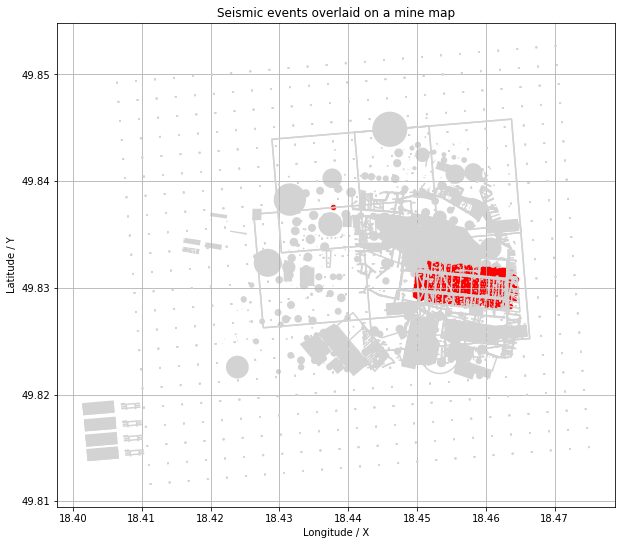

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
mines_map.plot(ax=ax, color='lightgray')
seismic_events.plot(ax=ax, color='red', markersize=20)

# thickness_between.plot(ax=ax, color='blue', edgecolor='black', alpha=0.7, label='Mocnost meziloží')

plt.title('Seismic events overlaid on a mine map')
# plt.legend()
plt.xlabel('Longitude / X')
plt.ylabel('Latitude / Y')
plt.grid(True)
plt.show()

Now this will be out of alignment:

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
mines_map.plot(ax=ax, color='lightgray')
seismic_events.plot(ax=ax, color='red', markersize=20)

thickness_between.plot(ax=ax, color='blue', edgecolor='black', alpha=0.7, label='Mocnost meziloží')

plt.title('Seismic events overlaid on a mine map')
# plt.legend()
plt.xlabel('Longitude / X')
plt.ylabel('Latitude / Y')
plt.grid(True)
plt.show()

In [ ]:
gdf = seismic_events.sample(200)

log_energy = np.log10(gdf.Energie.replace(0, np.nan)).dropna()
min_log_e, max_log_e = log_energy.min(), log_energy.max()

colormap = linear.YlOrRd_09.scale(min_log_e, max_log_e)
scaled_radius = lambda log_e: int(np.interp(log_e, [min_log_e, max_log_e], [4, 15]))

center = [seismic_events.geometry.y.mean(), seismic_events.geometry.x.mean()]
m = Map(center=center, zoom=14)

def add_seismic_events(m, events):
    # markers = []
    for _, row in events.iterrows():
        point = row.geometry
        log_e = np.log10(row.Energie)
    
        popup = Popup(
            location=(point.y, point.x),
            child=HTML(f'{row.Datetime} / E = {row.Energie}'),
        )
        
        marker = CircleMarker(
            location=(point.y, point.x),  # Leaflet uses (lat, lon)
            radius=scaled_radius(log_e),
            color=colormap(log_e),
            fill_color=colormap(log_e),
            fill_opacity=0.7,
            stroke=False,
            popup=popup,
        )
        
        m += marker
        # markers.append(marker)


def add_gdf(m, gdf, basecolormap, val_attr):
    colormap = basecolormap.scale(gdf[val_attr].min(), gdf[val_attr].max())

    for _, row in gdf.iterrows():
        point = row.geometry
        val = row[val_attr]
    
        popup = Popup(
            location=(point.y, point.x),
            child=HTML(f'{val}'),
        )
    
        marker = CircleMarker(
            location=(point.y, point.x),
            radius=4,
            color=colormap(val),
            fill_color=colormap(val),
            fill_opacity=0.7,
            stroke=False,
            popup=popup,
        )
        
        m += marker

add_gdf(m, depths_interpolated.sample(1000), linear.Accent_07, 'depth')
add_gdf(m, depths, linear.Blues_04, 'depth')
add_seismic_events(m, gdf)

# Unfortunately, layered elements do not support popups
# m += LayerGroup(layers=markers, name='Seismic events')
# m += LayersControl()

m